
ANALISI CASE STUDY: BAC
-> Trovato diem_log_BAC.bpmn. Conversione in PNML in corso...
-> Conversione e salvataggio completati.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 32429/32429 [00:14<00:00, 2175.76it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 15, Rete 2 ne ha 12
  -> Transizioni (Transitions): Rete 1 ne ha 22, Rete 2 ne ha 20
  -> Archi (Arcs): Rete 1 ne ha 44, Rete 2 ne ha 40
  -> Attività presenti SOLO nella Rete 1: {'Request completed with customer recovery', 'Request deleted'}

--- Metriche Rete 1 (diem_log_BAC.pnml) ---


aligning log, completed variants :: 100%|██████████| 187/187 [00:01<00:00, 148.14it/s]
computing precision with alignments, completed variants :: 100%|██████████| 475/475 [00:00<00:00, 792.25it/s]


Fitness:   0.9159
Precision: 0.9604
F-Score:   0.9376

--- Metriche Rete 2 (BAC_best_petri_net.pnml) ---


aligning log, completed variants :: 100%|██████████| 187/187 [00:01<00:00, 139.21it/s]
computing precision with alignments, completed variants :: 100%|██████████| 475/475 [00:01<00:00, 404.56it/s]


Fitness:   0.9437
Precision: 0.9035
F-Score:   0.9232

Stampo la Rete 1 (diem_log_BAC.pnml):


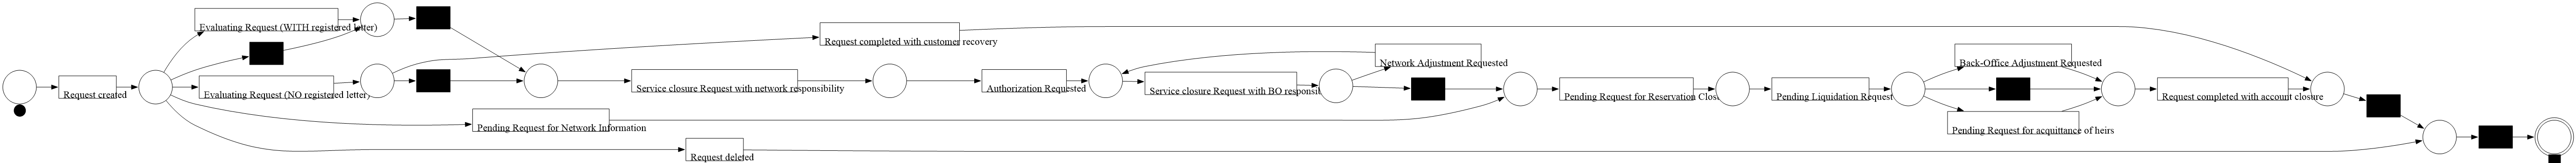


Stampo la Rete 2 (BAC_best_petri_net.pnml):


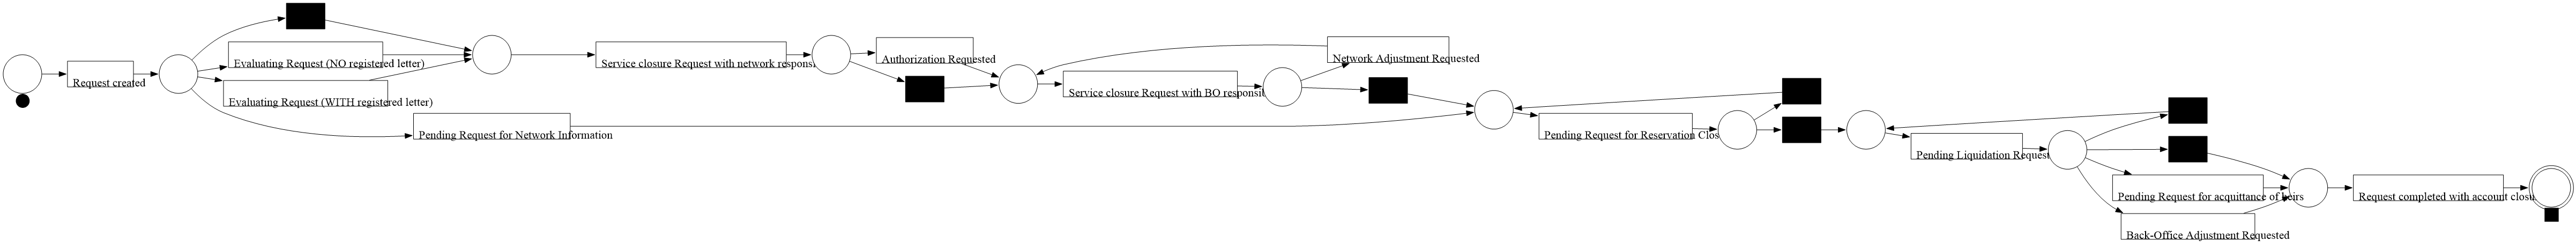




ANALISI CASE STUDY: BPI12
-> Trovato diem_log_BPI12.bpmn. Conversione in PNML in corso...
-> Conversione e salvataggio completati.

Caricamento dell'Event Log in corso...


parsing log, completed traces :: 100%|██████████| 4685/4685 [00:06<00:00, 739.24it/s]



--- Confronto Strutturale ---
Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:
  -> Posti (Places): Rete 1 ne ha 23, Rete 2 ne ha 27
  -> Transizioni (Transitions): Rete 1 ne ha 35, Rete 2 ne ha 45
  -> Archi (Arcs): Rete 1 ne ha 70, Rete 2 ne ha 90

--- Metriche Rete 1 (diem_log_BPI12.pnml) ---


aligning log, completed variants ::  76%|███████▋  | 2888/3776 [03:49<01:37,  9.10it/s]

In [ ]:
import os
import pm4py

# Imposta i percorsi e i nomi dei case study
base_path = r"C:\Users\Utente\Desktop\tesi magistrale\Code\multi_obj\case_studies"
case_studies = ["BAC", "BPI12", "bpi17_after", "bpi17_before"]

def confronta_reti(net1, net2):
    """
    Confronta due reti di Petri in base al numero di nodi/archi 
    e alle etichette delle transizioni (le attività).
    """
    t1_labels = {t.label for t in net1.transitions if t.label is not None}
    t2_labels = {t.label for t in net2.transitions if t.label is not None}

    n_t1, n_t2 = len(net1.transitions), len(net2.transitions)
    n_p1, n_p2 = len(net1.places), len(net2.places)
    n_a1, n_a2 = len(net1.arcs), len(net2.arcs)

    is_equal = (n_t1 == n_t2) and (n_p1 == n_p2) and (n_a1 == n_a2) and (t1_labels == t2_labels)
    
    differenze = []
    if not is_equal:
        if n_p1 != n_p2: differenze.append(f"Posti (Places): Rete 1 ne ha {n_p1}, Rete 2 ne ha {n_p2}")
        if n_t1 != n_t2: differenze.append(f"Transizioni (Transitions): Rete 1 ne ha {n_t1}, Rete 2 ne ha {n_t2}")
        if n_a1 != n_a2: differenze.append(f"Archi (Arcs): Rete 1 ne ha {n_a1}, Rete 2 ne ha {n_a2}")
        
        t_solo_1 = t1_labels - t2_labels
        t_solo_2 = t2_labels - t1_labels
        if t_solo_1: differenze.append(f"Attività presenti SOLO nella Rete 1: {t_solo_1}")
        if t_solo_2: differenze.append(f"Attività presenti SOLO nella Rete 2: {t_solo_2}")

    return is_equal, differenze


def calcola_metriche(log, net, im, fm):
    """Calcola Fitness, Precision (tramite alignments) e F-Score"""
    fitness_dict = pm4py.fitness_alignments(log, net, im, fm)
    fitness = fitness_dict['log_fitness'] 
    
    precision = pm4py.precision_alignments(log, net, im, fm)
    
    if (fitness + precision) > 0:
        f_score = 2 * (fitness * precision) / (fitness + precision)
    else:
        f_score = 0.0
        
    return fitness, precision, f_score


# Ciclo principale su tutti i dataset
for cs in case_studies:
    print(f"\n{'='*60}")
    print(f"ANALISI CASE STUDY: {cs}")
    print(f"{'='*60}")
    
    # Costruzione dei percorsi specifici
    discovery_dir = os.path.join(base_path, cs, "discovery_output")
    log_path = os.path.join(base_path, cs, f"log_{cs}.xes")
    
    bpmn_path = os.path.join(discovery_dir, f"diem_log_{cs}.bpmn")
    net1_pnml_path = os.path.join(discovery_dir, f"diem_log_{cs}.pnml")
    net2_pnml_path = os.path.join(discovery_dir, f"{cs}_best_petri_net.pnml")
    
    # 1. CONVERSIONE DA BPMN A PNML (Se il BPMN esiste e il PNML non è già stato creato)
    if os.path.exists(bpmn_path):
        if not os.path.exists(net1_pnml_path):
            print(f"-> Trovato {os.path.basename(bpmn_path)}. Conversione in PNML in corso...")
            try:
                bpmn_graph = pm4py.read_bpmn(bpmn_path)
                net_conv, im_conv, fm_conv = pm4py.convert_to_petri_net(bpmn_graph)
                pm4py.write_pnml(net_conv, im_conv, fm_conv, net1_pnml_path)
                print("-> Conversione e salvataggio completati.")
            except Exception as e:
                print(f"Errore durante la conversione del file BPMN: {e}")
                continue
        else:
            print(f"-> Il file {os.path.basename(net1_pnml_path)} esiste già. Salto la conversione.")
    else:
        print(f"ATTENZIONE: File BPMN {os.path.basename(bpmn_path)} non trovato. Assicurati che sia nella cartella corretta.")
        # Se manca il file sorgente, passiamo al prossimo case study
        if not os.path.exists(net1_pnml_path):
            continue
    
    # 2. CARICAMENTO DEL LOG
    if not os.path.exists(log_path):
        print(f"ATTENZIONE: File di log non trovato in {log_path}. Salto...")
        continue
        
    print("\nCaricamento dell'Event Log in corso...")
    log = pm4py.read_xes(log_path)
    
    # 3. CARICAMENTO DELLE RETI PNML DA CONFRONTARE
    try:
        net1, im1, fm1 = pm4py.read_pnml(net1_pnml_path)
        net2, im2, fm2 = pm4py.read_pnml(net2_pnml_path)
    except Exception as e:
        print(f"Errore nel caricamento dei file PNML per {cs}: {e}")
        continue

    # 4. CONFRONTO STRUTTURALE
    print("\n--- Confronto Strutturale ---")
    uguali, differenze = confronta_reti(net1, net2)
    
    if uguali:
        print("Le due reti di Petri hanno la STESSA STRUTTURA.")
    else:
        print("Le due reti di Petri sono DIVERSE. Ecco le differenze riscontrate:")
        for diff in differenze:
            print(f"  -> {diff}")
            
    # 5. CALCOLO METRICHE RETE 1 (diem_log)
    print(f"\n--- Metriche Rete 1 ({os.path.basename(net1_pnml_path)}) ---")
    try:
        fit1, prec1, fs1 = calcola_metriche(log, net1, im1, fm1)
        print(f"Fitness:   {fit1:.4f}")
        print(f"Precision: {prec1:.4f}")
        print(f"F-Score:   {fs1:.4f}")
    except Exception as e:
        print(f"Impossibile calcolare metriche per Rete 1: {e}")

    # 6. CALCOLO METRICHE RETE 2 (best_petri_net)
    print(f"\n--- Metriche Rete 2 ({os.path.basename(net2_pnml_path)}) ---")
    try:
        fit2, prec2, fs2 = calcola_metriche(log, net2, im2, fm2)
        print(f"Fitness:   {fit2:.4f}")
        print(f"Precision: {prec2:.4f}")
        print(f"F-Score:   {fs2:.4f}")
    except Exception as e:
        print(f"Impossibile calcolare metriche per Rete 2: {e}")

    # 7. VISUALIZZAZIONE RETI
    if uguali:
        print("\nStampo la rete a schermo (le reti sono identiche):")
        pm4py.view_petri_net(net1, im1, fm1)
    else:
        print(f"\nStampo la Rete 1 ({os.path.basename(net1_pnml_path)}):")
        pm4py.view_petri_net(net1, im1, fm1)
        print(f"\nStampo la Rete 2 ({os.path.basename(net2_pnml_path)}):")
        pm4py.view_petri_net(net2, im2, fm2)
        
    print("\n")